In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
df = pd.read_csv(r"../data/raw/IMDB Dataset.csv")

In [3]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
duplicate = df.duplicated()
df[duplicate]

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,My favourite police series of all time turns t...,positive
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive
6352,If you liked the Grinch movie... go watch that...,negative
6479,I want very much to believe that the above quo...,negative
...,...,...
49912,This is an incredible piece of drama and power...,positive
49950,This was a very brief episode that appeared in...,negative
49984,Hello it is I Derrick Cannon and I welcome you...,negative
49986,This movie is a disgrace to the Major League F...,negative


In [6]:
#here duplicate column is being identifeid no of row is 418 

In [7]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [8]:
df["sentiment"].unique()

<StringArray>
['positive', 'negative']
Length: 2, dtype: str

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [10]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [11]:
repeated = df['review'].duplicated()
df[repeated]

,review,sentiment
3537,Quite what the producers of this appalling ada...,negative
3769,My favourite police series of all time turns t...,positive
4391,"Beautiful film, pure Cassavetes style. Gena Ro...",positive
6352,If you liked the Grinch movie... go watch that...,negative
6479,I want very much to believe that the above quo...,negative
...,...,...
49912,This is an incredible piece of drama and power...,positive
49950,This was a very brief episode that appeared in...,negative
49984,Hello it is I Derrick Cannon and I welcome you...,negative
49986,This movie is a disgrace to the Major League F...,negative


In [12]:
#count of positive reviews

In [13]:
positive  = df["sentiment"] == "positive"

df[positive]

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
49983,"I loved it, having been a fan of the original ...",positive
49985,Imaginary Heroes is clearly the best film of t...,positive
49989,I got this one a few weeks ago and love it! It...,positive
49992,John Garfield plays a Marine who is blinded by...,positive


In [14]:
#there are 25000 positive review that may include duplicates

In [15]:
negative  = df["sentiment"] == "negative"

df[negative]

,review,sentiment
3,Basically there's a family where a little boy ...,negative
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
10,Phil the Alien is one of those quirky films wh...,negative
11,I saw this movie when I was about 12 when it c...,negative
...,...,...
49994,This is your typical junk comedy.<br /><br />T...,negative
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [16]:
#there 25000 negative review 

In [17]:
#percentage calculation

positive_per = (len(df[positive])/len(df))*100

negative_per = 100 - positive_per

df['count'] = df['review'].str.split().str.len()

print(f" positive review percentage is {positive_per}\n"
      f" negative review percentage is {negative_per}\n"
      f"max lengthed review size is {df['count'].max()}\n"
      f"median of lenght is {df['count'].median()}")



 positive review percentage is 50.0
 negative review percentage is 50.0
max lengthed review size is 2470
median of lenght is 173.0


In [18]:
#sentiment distribution

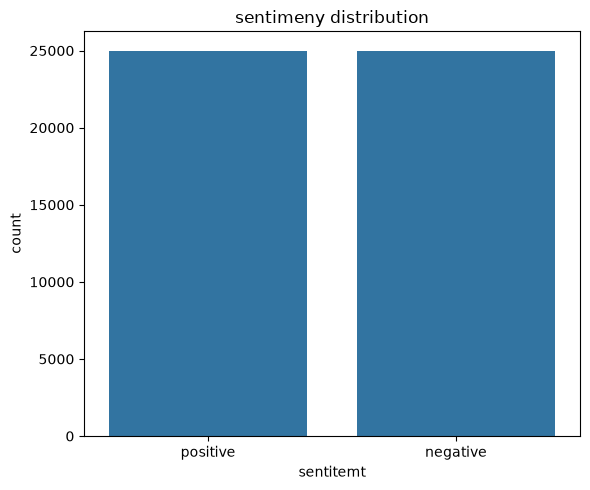

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="sentiment")
plt.title("sentimeny distribution")
plt.xlabel("sentitemt")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(r'../static/images/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
#review length distribution

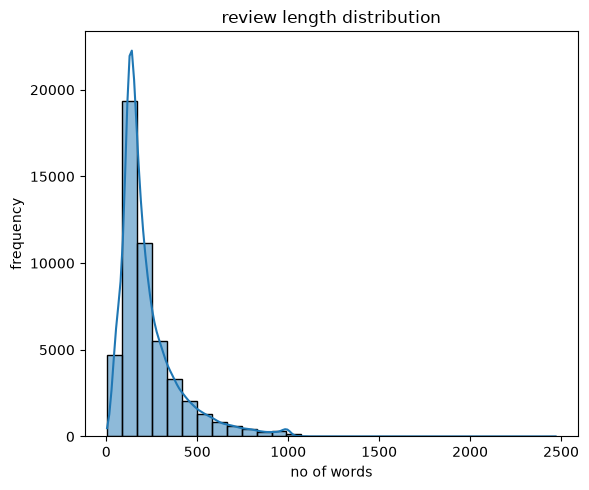

In [21]:
plt.figure(figsize=(6,5))
sns.histplot(data=df,x="count",bins=30, kde=True)
plt.title("review length distribution")
plt.xlabel("no of words")
plt.ylabel("frequency")
plt.tight_layout()
plt.savefig(r'../static/images/review_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
all_words = df['review'].str.lower().str.cat(sep=' ').split()
word_counts = pd.Series(all_words).value_counts()
word_counts

the               638861
a                 316615
and               313637
of                286661
to                264573
                   ...  
tragedy...the          1
students...the         1
mom),                  1
botch,                 1
yosemite.<br           1
Name: count, Length: 390931, dtype: int64

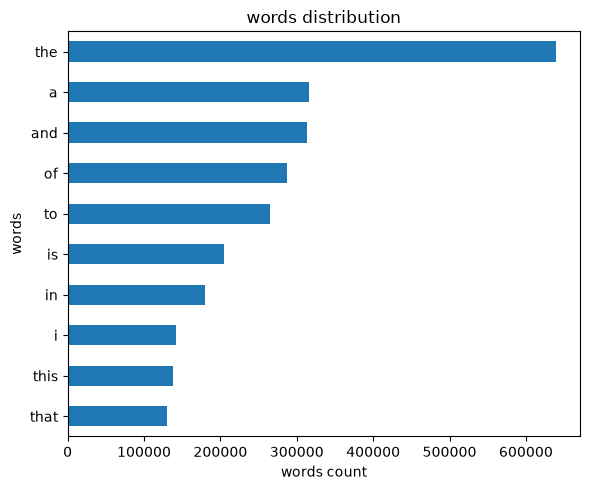

In [23]:
plt.figure(figsize=(6,5))
word_counts.head(10).sort_values().plot(kind="barh")
plt.title("words distribution")
plt.xlabel("words count")
plt.ylabel("words")
plt.tight_layout()
plt.savefig(r'../static/images/words_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

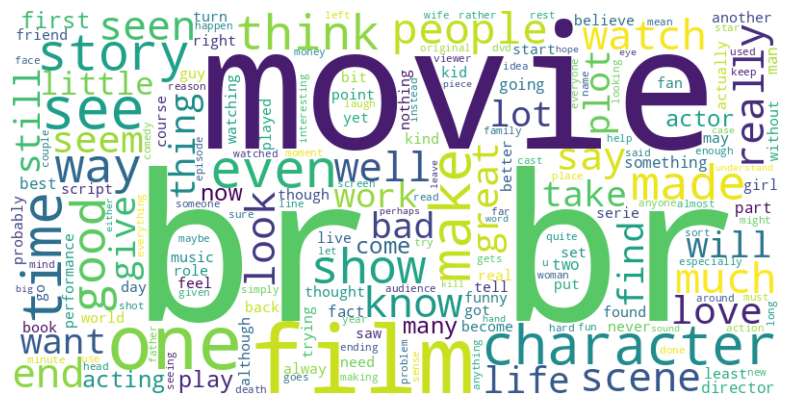

In [24]:
all_words = df['review'].str.lower().str.cat(sep=' ')

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig(r'../static/images/wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()